# はじめに
このNotebookは``NakaMetPy``の``util``パッケージの利用シーンをまとめたwikiです。なお各関数の例はドキュメンテーションやdocstringに記載しているため、そちらも合わせて参照してください。

# 掲載している関数一覧
- load_jmara_grib2

# 利用シーン
## シーン1：1kmメッシュのレーダー反射強度をプロットしたい
5分間隔の1kmメッシュレーダー反射強度をプロットします。なお瞬間値なので、1時間降水量として研究に用いる場合は、5分ごとの雨量を積算&平均し、1時間降水量として下さい。

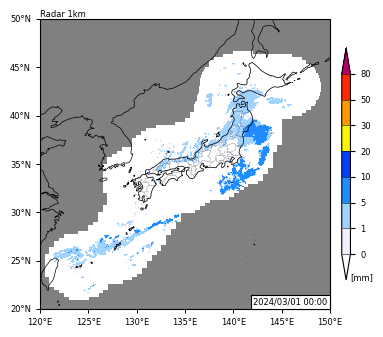

In [7]:
import numpy as np
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.io.shapereader as shapereader
import matplotlib.pyplot as plt 
from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import BoundaryNorm
from nakametpy.cmaps import jma_list_9lev
from nakametpy.util import (
  load_jmara_grib2, jma_rain_lat, jma_rain_lon,
)
from datetime import datetime as dt
import datetime
import os

%matplotlib inline

fontsize = 6
region = [120, 150, 20, 50]
cmp = jma_list_9lev

cbar_ticks = np.array([0, 1, 5, 10, 20, 30, 50, 80])
norm = BoundaryNorm(cbar_ticks, cmp.N, extend='both')

shpfilename = shapereader.natural_earth(resolution='10m',
                                        category='cultural',
                                        name='admin_1_states_provinces')


radar = load_jmara_grib2("../tests/data/util/load_jmara_grib2/Z__C_RJTD_20240301000000_RDR_GPV_Ggis1km_Phhlv_Aper5min_ANAL_grib2.bin")

fig = plt.figure(figsize=(4, 4))
# Generate axes, using Cartopy, drawing coastlines, and adding features
projection = ccrs.PlateCarree()
fig.subplots_adjust(right=0.85)
ax = fig.add_subplot(1, 1, 1, projection=projection)
ax.coastlines(linewidths=0.5, zorder=2)

# 都道府県境を描く
provinces = shapereader.Reader(shpfilename).records()
prefs = filter(lambda province: province.attributes['admin'] == 'Japan', provinces)
for pref in prefs:
    geometry = pref.geometry
    ax.add_geometries([geometry], ccrs.PlateCarree(), linestyle=':', facecolor="none", edgecolor="black", lw=0.2, zorder=2)

# frameの設定をする
ax.set_facecolor('.5')
xticks = np.arange(120, 150.1, 5)
yticks = np.arange(20, 50.1, 5)
ax.set_xticks(xticks, crs=projection)
ax.set_yticks(yticks, crs=projection)
ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.tick_params(direction='out', length=3, width=0.7, colors='k',
    grid_color='k', grid_alpha=0.5, labelsize=fontsize)
ax.set_extent(region, crs=projection)


# contourfで陰影をプロット
pv_plot = ax.contourf(jma_rain_lon, jma_rain_lat, radar,
                        transform=projection,
                        levels=cbar_ticks,
                        cmap=cmp, norm=norm,
                        extend='both', corner_mask=False, zorder=1)

cax = ax.inset_axes([1.04, 0.1, 0.03, 0.8], transform=ax.transAxes)
# Add color bar
cbar = plt.colorbar(pv_plot, cax = cax, orientation='vertical',
                    extendfrac = 'auto', 
                    ticks=cbar_ticks, drawedges=True
                    )

cbar.ax.tick_params(labelsize=fontsize)


text_topleft = AnchoredText(f'Radar 1km', loc='lower left', prop=dict(size=fontsize), pad=0, borderpad=0., frameon=False, 
                    bbox_to_anchor=(0., 1.), bbox_transform=ax.transAxes)
ax.add_artist(text_topleft)
text_time = AnchoredText(f'2024/03/01 00:00', loc='lower right', prop=dict(size=fontsize), pad=0.3, borderpad=0., frameon=True, )
ax.add_artist(text_time)
# https://stackoverflow.com/questions/33634522/set-linewidth-and-facecolor-of-an-anchoredoffsetbox
text_time.patch.set_linewidth(ax.spines['left'].get_linewidth())
ax.text(1.07, 0.1, '[mm]', fontsize=fontsize, transform=ax.transAxes)

plt.show()